<a href="https://colab.research.google.com/github/anishkr-sahu/revision_ml/blob/main/ml_day_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# step -1 setup and data loading
import pandas as pd


In [2]:
df = pd.read_csv("/content/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# step -2 data exploration
print(df.shape)
print(df.info())
print(df.describe())


(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842 

In [7]:
print(df.isnull().sum())

Survived    0
Age         0
Sex         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [5]:
# step -3 feature selection
df = df[['Survived','Age','Sex','SibSp','Parch','Fare','Embarked']]

In [6]:
# step -4 data cleaning
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_591/88677611.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_591/88677611.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [10]:
df.head()

,Survived,Age,Sex,SibSp,Parch,Fare,Embarked
0,0,22.0,1,1,0,7.2500,2
1,1,38.0,0,1,0,71.2833,0
2,1,26.0,0,0,0,7.9250,2
3,1,35.0,0,1,0,53.1000,2
4,0,35.0,1,0,0,8.0500,2


In [9]:
# encode
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [11]:
# step -5 split data into X(independent variable) and Y(dependent variable)
X = df.drop('Survived', axis=1)
Y = df['Survived']

In [12]:
# train and test split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [14]:
# step -6 standardization  (independent variable)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [16]:
# step -7 model training
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 4,
    random_state =42
)
model.fit(X_train_scaled,Y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [18]:
# step -8 prediction
Y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)
print(Y_test)
print(y_prob)
print(Y_pred)

709    1
439    0
840    0
720    1
39     1
      ..
433    0
773    0
25     1
84     1
10     1
Name: Survived, Length: 179, dtype: int64
[[0.89263804 0.10736196]
 [0.89263804 0.10736196]
 [0.89263804 0.10736196]
 [0.125      0.875     ]
 [0.125      0.875     ]
 [0.125      0.875     ]
 [0.33333333 0.66666667]
 [0.89263804 0.10736196]
 [0.33333333 0.66666667]
 [0.125      0.875     ]
 [0.66019417 0.33980583]
 [0.89263804 0.10736196]
 [0.92857143 0.07142857]
 [0.89263804 0.10736196]
 [0.89263804 0.10736196]
 [0.125      0.875     ]
 [0.66019417 0.33980583]
 [0.33333333 0.66666667]
 [0.89263804 0.10736196]
 [0.66019417 0.33980583]
 [0.89263804 0.10736196]
 [0.66019417 0.33980583]
 [0.33333333 0.66666667]
 [0.89263804 0.10736196]
 [0.89263804 0.10736196]
 [1.         0.        ]
 [0.66019417 0.33980583]
 [0.89263804 0.10736196]
 [0.66666667 0.33333333]
 [0.33333333 0.66666667]
 [0.89263804 0.10736196]
 [0.33333333 0.66666667]
 [0.66019417 0.33980583]
 [0.33333333 0.66666667]
 [0.89263

In [19]:
# step -9 metrics evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy: ", accuracy_score(Y_test, Y_pred))
print("Confusion report: ", classification_report(Y_test, Y_pred))
print("Confusion matrix: ", confusion_matrix(Y_test, Y_pred))


Accuracy:  0.8044692737430168
Confusion report:                precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

Confusion matrix:  [[91 14]
 [21 53]]


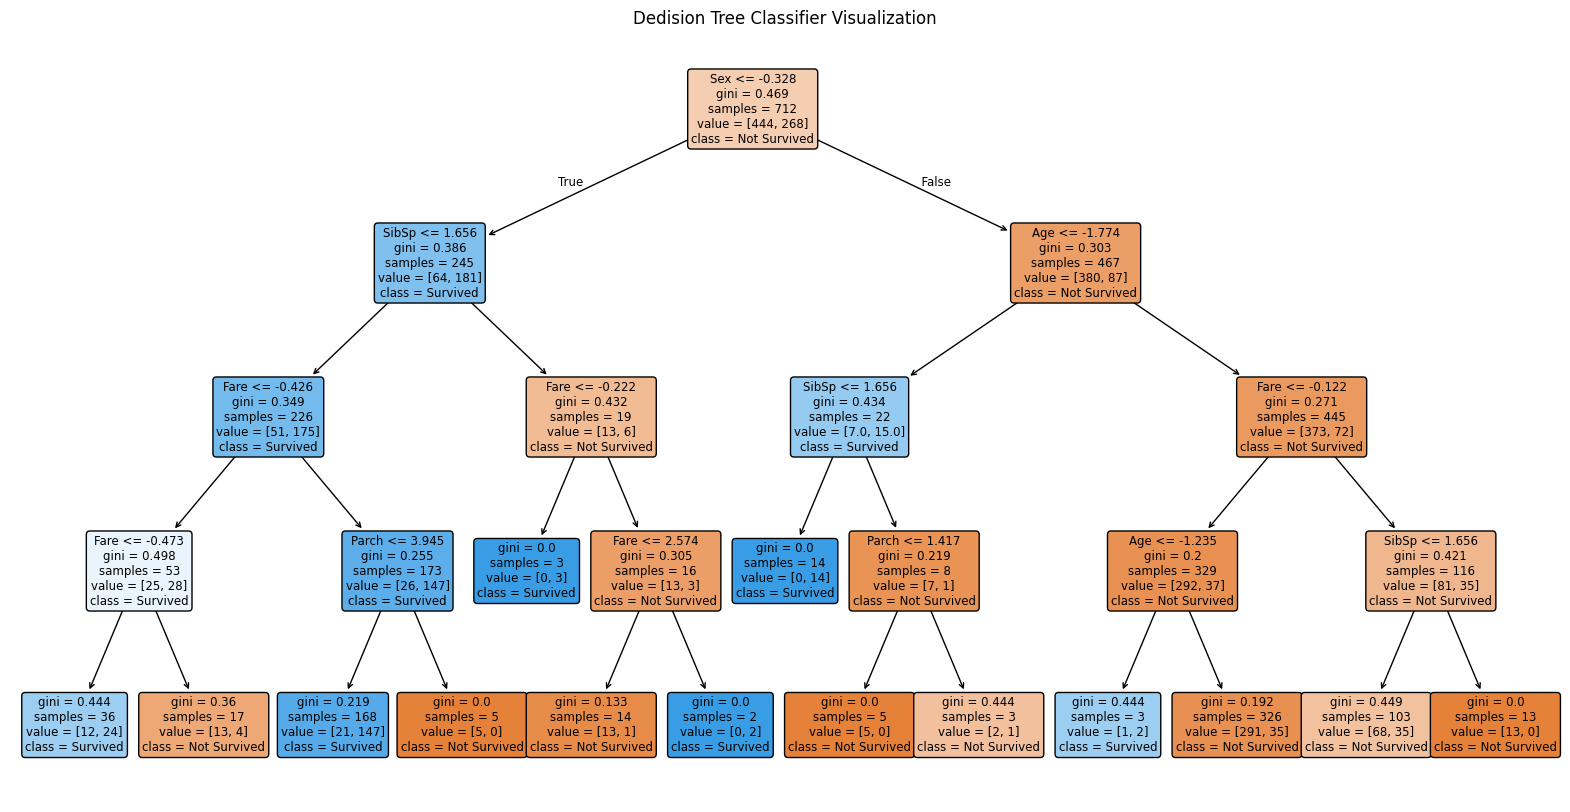

In [20]:
# step -10 visualization
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['Not Survived','Survived'], filled=True, rounded=True)
plt.title("Dedision Tree Classifier Visualization")
plt.show()

In [21]:
# step -11 emprovement ( different model or bagging and boosting)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid ={
    'n_estimators': [50,100,200],  # number of tress in the forest
    'max_depth': [None,10,20,30],  # maximum depth of the tree
    'min_samples_split': [2,5,10], # minimum number of samples required to split an internal node
    'min_samples_leaf': [1,2,4],   # Minimum number of samples required to be at a leaf node
    'criterion': ['gini','entropy']  # function to measure the quality of a split
}

rf = RandomForestClassifier(random_state =42)
grid_search = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    cv = 5,
    n_jobs = -1,
    verbose = 2,
    scoring = 'accuracy'
)

grid_search.fit(X_train_scaled, Y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=2)

In [22]:
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)

best_rf_model = grid_search.best_estimator_

Best parameters found:  {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best accuracy found:  0.8201615286122328


In [23]:
best_rf_pred = best_rf_model.predict(X_test_scaled)
print("Accuracy: ",accuracy_score(Y_test, best_rf_pred))
print("Confusion matrix: ",confusion_matrix(Y_test, best_rf_pred))
print("Classification report: ", classification_report(Y_test, best_rf_pred))

Accuracy:  0.8156424581005587
Confusion matrix:  [[92 13]
 [20 54]]
Classification report:                precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179



### Exploring Boosting Techniques

#### 1. AdaBoost Classifier

In [24]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

adaboost_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=42)
adaboost_model.fit(X_train_scaled, Y_train)

y_pred_adaboost = adaboost_model.predict(X_test_scaled)
print('AdaBoost Classifier Accuracy:', accuracy_score(Y_test, y_pred_adaboost))
print('AdaBoost Confusion Matrix:\n', confusion_matrix(Y_test, y_pred_adaboost))
print('AdaBoost Classification Report:\n', classification_report(Y_test, y_pred_adaboost))

AdaBoost Classifier Accuracy: 0.7988826815642458
AdaBoost Confusion Matrix:
 [[89 16]
 [20 54]]
AdaBoost Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



#### 2. Gradient Boosting Classifier

In [25]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boost_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gradient_boost_model.fit(X_train_scaled, Y_train)

y_pred_gradient = gradient_boost_model.predict(X_test_scaled)
print('Gradient Boosting Classifier Accuracy:', accuracy_score(Y_test, y_pred_gradient))
print('Gradient Boosting Confusion Matrix:\n', confusion_matrix(Y_test, y_pred_gradient))
print('Gradient Boosting Classification Report:\n', classification_report(Y_test, y_pred_gradient))

Gradient Boosting Classifier Accuracy: 0.8100558659217877
Gradient Boosting Confusion Matrix:
 [[91 14]
 [20 54]]
Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



#### 3. XGBoost Classifier

In [26]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=3, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, Y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
print('XGBoost Classifier Accuracy:', accuracy_score(Y_test, y_pred_xgb))
print('XGBoost Confusion Matrix:\n', confusion_matrix(Y_test, y_pred_xgb))
print('XGBoost Classification Report:\n', classification_report(Y_test, y_pred_xgb))

XGBoost Classifier Accuracy: 0.8044692737430168
XGBoost Confusion Matrix:
 [[91 14]
 [21 53]]
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [01:09:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#### 4. CatBoost Classifier

In [30]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.2 MB/s eta 0:00:00


In [31]:
import catboost as cb

catboost_model = cb.CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3, random_state=42, verbose=False)
catboost_model.fit(X_train_scaled, Y_train)

y_pred_catboost = catboost_model.predict(X_test_scaled)
print('CatBoost Classifier Accuracy:', accuracy_score(Y_test, y_pred_catboost))
print('CatBoost Confusion Matrix:\n', confusion_matrix(Y_test, y_pred_catboost))
print('CatBoost Classification Report:\n', classification_report(Y_test, y_pred_catboost))

CatBoost Classifier Accuracy: 0.7988826815642458
CatBoost Confusion Matrix:
 [[90 15]
 [21 53]]
CatBoost Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



#### 5. LightGBM Classifier

In [28]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, num_leaves=31, random_state=42)
lgb_model.fit(X_train_scaled, Y_train)

y_pred_lgb = lgb_model.predict(X_test_scaled)
print('LightGBM Classifier Accuracy:', accuracy_score(Y_test, y_pred_lgb))
print('LightGBM Confusion Matrix:\n', confusion_matrix(Y_test, y_pred_lgb))
print('LightGBM Classification Report:\n', classification_report(Y_test, y_pred_lgb))

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000219 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Model Performance Comparison

/tmp/ipykernel_591/2265063654.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracy_scores, palette='viridis')


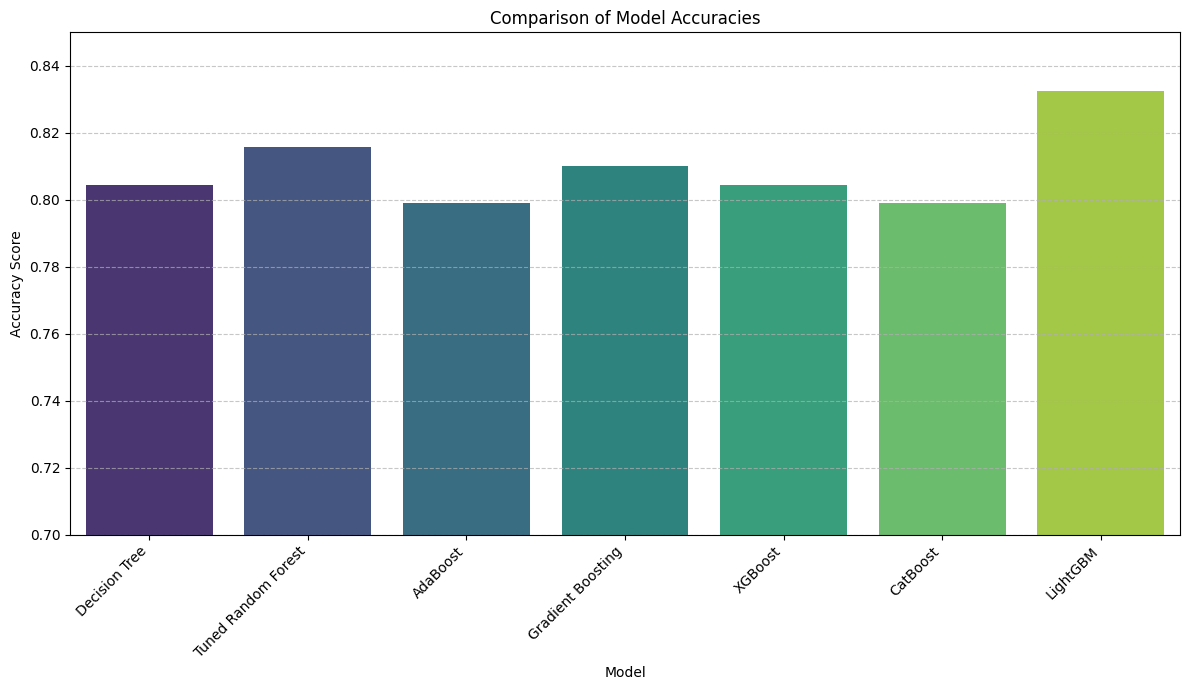

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect accuracy scores from previously run models
accuracies = {
    'Decision Tree': accuracy_score(Y_test, Y_pred),
    'Tuned Random Forest': accuracy_score(Y_test, best_rf_pred),
    'AdaBoost': accuracy_score(Y_test, y_pred_adaboost),
    'Gradient Boosting': accuracy_score(Y_test, y_pred_gradient),
    'XGBoost': accuracy_score(Y_test, y_pred_xgb),
    'CatBoost': accuracy_score(Y_test, y_pred_catboost),
    'LightGBM': accuracy_score(Y_test, y_pred_lgb)
}

models = list(accuracies.keys())
accuracy_scores = list(accuracies.values())

# Create a bar chart for accuracy comparison
plt.figure(figsize=(12, 7))
sns.barplot(x=models, y=accuracy_scores, palette='viridis')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.title('Comparison of Model Accuracies')
plt.ylim(0.7, 0.85) # Set y-axis limits to focus on the performance range
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [33]:
import numpy as np
import pandas as pd

# Metric Imports
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Model Imports
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Advanced Boosting Libraries
import xgboost as xgb
import catboost as cb
import lightgbm as lgb


# =====================================================================
# 1. BAGGING MODELS (PARALLEL COMBINATIONS)
# =====================================================================
print("\n" + "="*50)
print("1. RUNNING BAGGING MODELS (PARALLEL ENSEMBLES)")
print("="*50)

# A. Random Forest Hyperparameter Tuning (GridSearchCV)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy']
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy'
)

print("\n--- Tuning Random Forest with GridSearchCV ---")
grid_search.fit(X_train_scaled, Y_train)
best_rf_model = grid_search.best_estimator_

print("Best RF Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

best_rf_pred = best_rf_model.predict(X_test_scaled)
print("Random Forest Test Accuracy:", accuracy_score(Y_test, best_rf_pred))


# =====================================================================
# 2. BOOSTING MODELS (SEQUENTIAL COMBINATIONS)
# =====================================================================
print("\n" + "="*50)
print("2. RUNNING BOOSTING MODELS (SEQUENTIAL ENSEMBLES)")
print("="*50)

# Define all boosting algorithms in a dictionary
boosting_models = {
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    'XGBoost': xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        eval_metric='logloss',
        random_state=42
    ),

    'CatBoost': cb.CatBoostClassifier(
        iterations=100,
        learning_rate=0.1,
        depth=3,
        random_state=42,
        verbose=False
    ),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )
}

# Loop through and evaluate each Boosting model
boosting_results = {}

for name, model in boosting_models.items():
    model.fit(X_train_scaled, Y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(Y_test, y_pred)
    boosting_results[name] = (model, y_pred, acc)
    print(f"{name} Test Accuracy: {acc:.4f}")


# =====================================================================
# 3. HYBRID META-ENSEMBLE (VOTING & STACKING COMBINATION)
# =====================================================================
print("\n" + "="*50)
print("3. HYBRID ENSEMBLE (COMBINING BAGGING + BOOSTING)")
print("="*50)

# A. Voting Classifier (Combines Best Bagging + Top Boosting Models)
voting_model = VotingClassifier(
    estimators=[
        ('rf', best_rf_model),
        ('xgb', boosting_models['XGBoost']),
        ('cat', boosting_models['CatBoost']),
        ('lgb', boosting_models['LightGBM'])
    ],
    voting='soft'
)

voting_model.fit(X_train_scaled, Y_train)
y_pred_voting = voting_model.predict(X_test_scaled)
print(f"Voting Classifier Test Accuracy: {accuracy_score(Y_test, y_pred_voting):.4f}")


# B. Stacking Classifier (Uses Logistic Regression as Meta-Learner)
stacking_model = StackingClassifier(
    estimators=[
        ('rf', best_rf_model),
        ('xgb', boosting_models['XGBoost']),
        ('cat', boosting_models['CatBoost']),
        ('lgb', boosting_models['LightGBM'])
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

stacking_model.fit(X_train_scaled, Y_train)
y_pred_stacking = stacking_model.predict(X_test_scaled)
print(f"Stacking Classifier Test Accuracy: {accuracy_score(Y_test, y_pred_stacking):.4f}")


# =====================================================================
# 4. FINAL COMPARISON BOARD & DETAILED EVALUATION
# =====================================================================
print("\n" + "="*50)
print("4. FINAL MODEL PERFORMANCE COMPARISON")
print("="*50)

# Aggregate all predictions
all_predictions = {
    'Random Forest (Tuned Bagging)': (best_rf_pred, accuracy_score(Y_test, best_rf_pred)),
    'AdaBoost': (boosting_results['AdaBoost'][1], boosting_results['AdaBoost'][2]),
    'Gradient Boosting': (boosting_results['Gradient Boosting'][1], boosting_results['Gradient Boosting'][2]),
    'XGBoost': (boosting_results['XGBoost'][1], boosting_results['XGBoost'][2]),
    'CatBoost': (boosting_results['CatBoost'][1], boosting_results['CatBoost'][2]),
    'LightGBM': (boosting_results['LightGBM'][1], boosting_results['LightGBM'][2]),
    'Voting Ensemble (Soft)': (y_pred_voting, accuracy_score(Y_test, y_pred_voting)),
    'Stacking Ensemble': (y_pred_stacking, accuracy_score(Y_test, y_pred_stacking))
}

# Create Comparison DataFrame
summary_df = pd.DataFrame([
    {'Model': name, 'Accuracy': acc}
    for name, (_, acc) in all_predictions.items()
]).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print(summary_df)

# Print Detailed Report for the Best Performing Model
best_model_name = summary_df.iloc[0]['Model']
best_predictions = all_predictions[best_model_name][0]

print("\n" + "="*50)
print(f"BEST MODEL DETAILED REPORT: {best_model_name}")
print("="*50)
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, best_predictions))
print("\nClassification Report:\n", classification_report(Y_test, best_predictions))


1. RUNNING BAGGING MODELS (PARALLEL ENSEMBLES)

--- Tuning Random Forest with GridSearchCV ---
Best RF Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best CV Accuracy: 0.8187924751305033
Random Forest Test Accuracy: 0.8100558659217877

2. RUNNING BOOSTING MODELS (SEQUENTIAL ENSEMBLES)
AdaBoost Test Accuracy: 0.7989
Gradient Boosting Test Accuracy: 0.8101
XGBoost Test Accuracy: 0.8045
CatBoost Test Accuracy: 0.7989
LightGBM Test Accuracy: 0.8324

3. HYBRID ENSEMBLE (COMBINING BAGGING + BOOSTING)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Voting Classifier Test Accuracy: 0.8045


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Stacking Classifier Test Accuracy: 0.7989

4. FINAL MODEL PERFORMANCE COMPARISON
                           Model  Accuracy
0                       LightGBM  0.832402
1  Random Forest (Tuned Bagging)  0.810056
2              Gradient Boosting  0.810056
3                        XGBoost  0.804469
4         Voting Ensemble (Soft)  0.804469
5                       AdaBoost  0.798883
6                       CatBoost  0.798883
7              Stacking Ensemble  0.798883

BEST MODEL DETAILED REPORT: LightGBM

Confusion Matrix:
 [[91 14]
 [16 58]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86       105
           1       0.81      0.78      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
